In [3]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
#Load Dataset
df = pd.read_csv("creditcard.csv")

print(df.shape)
df.head()

(9965, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [6]:
#Check Class Imbalance
print(df["Class"].value_counts())

Class
0.0    9926
1.0      38
Name: count, dtype: int64


In [7]:
# Check Missing Values
print("Missing values in Class:", df["Class"].isna().sum())

# Remove Rows with Missing Target
df = df.dropna(subset=["Class"])

# Separate Features and Target
X = df.drop("Class", axis=1)
y = df["Class"]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Missing values in Class: 1
Training data: (7971, 30)
Testing data: (1993, 30)


In [8]:
#Train Random Forest

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42)

In [9]:
#Make Predictions
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9984947315604616

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1985
         1.0       1.00      0.62      0.77         8

    accuracy                           1.00      1993
   macro avg       1.00      0.81      0.88      1993
weighted avg       1.00      1.00      1.00      1993



In [10]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1985    0]
 [   3    5]]


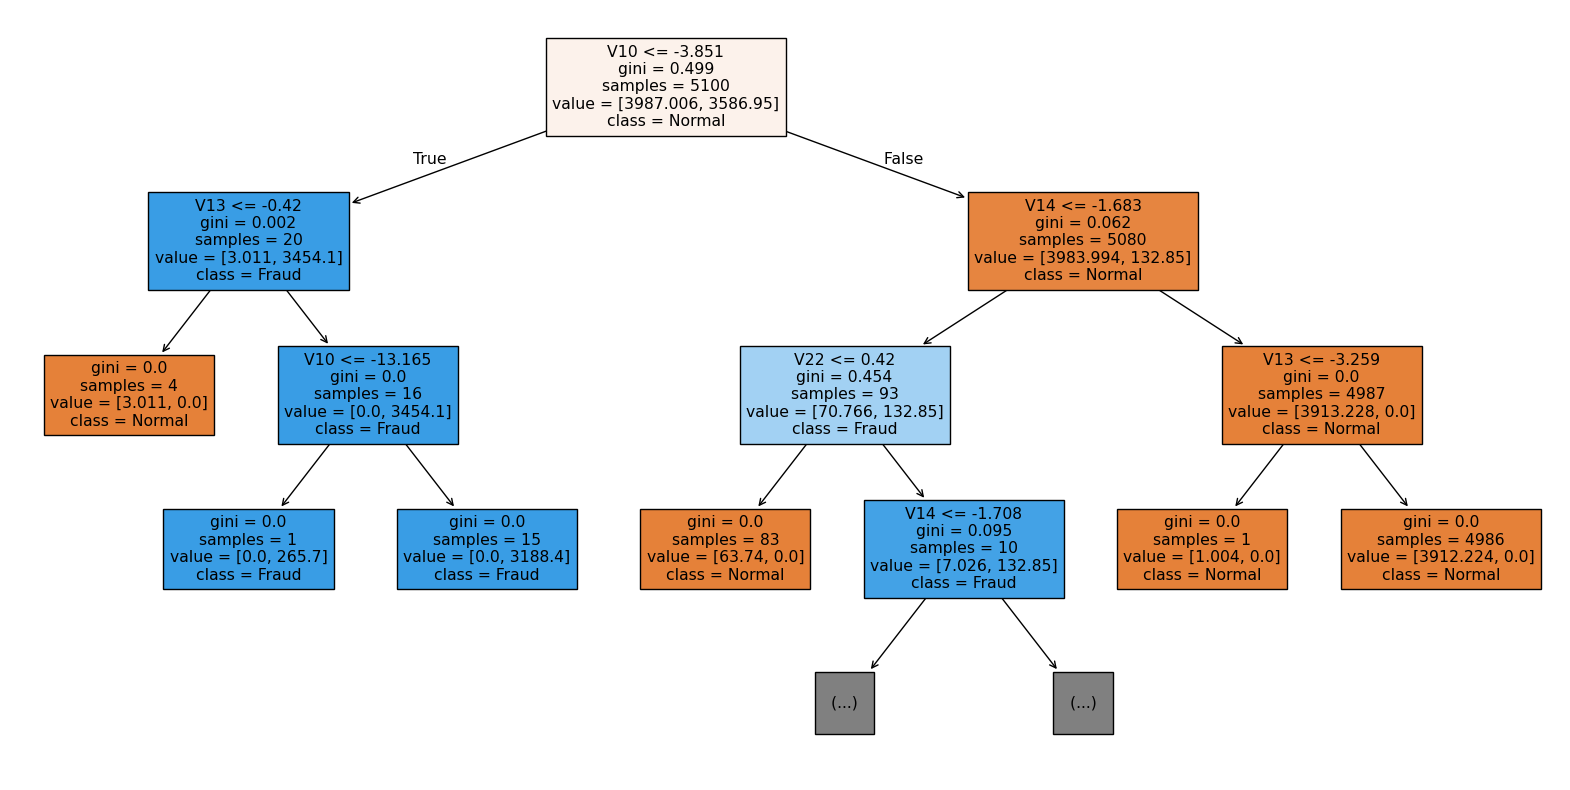

In [11]:
#Visualise Random Forest
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    rf.estimators_[50],
    max_depth=3,
    feature_names=X.columns,
    class_names=["Normal", "Fraud"],
    filled=True
)

plt.show()